In [1]:
import pandas as pd
import numpy as np

# Load optimized Q50 plan
optimized_plan = pd.read_csv(
    "../data/processed/optimized_plan.csv",
    parse_dates=["date"]
)

# Load uncertainty-aware plan
optimized_uncertain = pd.read_csv(
    "../data/processed/optimized_uncertain_plan.csv",
    parse_dates=["date"]
)

print("Q50 plan:", optimized_plan.shape)
print("Uncertainty-aware plan:", optimized_uncertain.shape)

Q50 plan: (520, 6)
Uncertainty-aware plan: (520, 6)


In [2]:
np.random.seed(42)

n_simulations = 100

scenarios = []

for sim in range(n_simulations):

    scenario = optimized_plan[
        ["date", "item", "forecast_demand"]
    ].copy()

    scenario["simulation"] = sim + 1

    scenario["actual_demand"] = (
        scenario["forecast_demand"]
        * np.random.normal(
            loc=1.0,
            scale=0.10,
            size=len(scenario)
        )
    )

    scenario["actual_demand"] = (
        scenario["actual_demand"].clip(lower=0)
    )

    scenarios.append(scenario)

scenarios = pd.concat(
    scenarios,
    ignore_index=True
)

print("Scenarios created:", scenarios.shape)

Scenarios created: (52000, 5)


In [3]:
q50_results = []

for sim in range(1, n_simulations + 1):

    scenario = scenarios[
        scenarios["simulation"] == sim
    ].copy()

    inventory_by_item = {}

    for item in sorted(optimized_plan["item"].unique()):

        inventory = 0

        item_scenario = (
            scenario[scenario["item"] == item]
            .sort_values("date")
        )

        item_plan = (
            optimized_plan[
                optimized_plan["item"] == item
            ]
            .sort_values("date")
        )

        for (_, demand_row), (_, plan_row) in zip(
            item_scenario.iterrows(),
            item_plan.iterrows()
        ):

            actual_demand = demand_row["actual_demand"]
            production = plan_row["production"]

            available = inventory + production

            sales = min(
                available,
                actual_demand
            )

            ending_inventory = (
                available - sales
            )

            stockout = (
                actual_demand - sales
            )

            q50_results.append({
                "simulation": sim,
                "date": demand_row["date"],
                "item": item,
                "actual_demand": actual_demand,
                "production": production,
                "sales": sales,
                "ending_inventory": ending_inventory,
                "stockout": stockout
            })

            inventory = ending_inventory

q50_results = pd.DataFrame(q50_results)

print("Q50 Monte Carlo results:", q50_results.shape)
q50_results.head()

Q50 Monte Carlo results: (52000, 8)


,simulation,date,item,actual_demand,production,sales,ending_inventory,stockout
0,1,2017-07-09,1,2390.455805,2277.337242,2277.337242,0.0,113.118564
1,1,2017-07-16,1,2577.501852,2248.020940,2248.020940,0.0,329.480912
2,1,2017-07-23,1,2453.391085,0.000000,0.000000,0.0,2453.391085
3,1,2017-07-30,1,2172.027313,0.000000,0.000000,0.0,2172.027313
4,1,2017-08-06,1,2066.190552,0.000000,0.000000,0.0,2066.190552


In [4]:
q50_summary = (
    q50_results
    .groupby("simulation")
    .agg(
        total_demand=("actual_demand", "sum"),
        total_sales=("sales", "sum"),
        total_stockout=("stockout", "sum"),
        final_inventory=("ending_inventory", "last")
    )
    .reset_index()
)

q50_summary["service_level"] = (
    q50_summary["total_sales"]
    / q50_summary["total_demand"]
)

q50_summary["stockout_rate"] = (
    q50_summary["total_stockout"]
    / q50_summary["total_demand"]
)

q50_summary.head()

,simulation,total_demand,total_sales,total_stockout,final_inventory,service_level,stockout_rate
0,1,2.318596e+06,1.978177e+06,340418.655537,20218.010407,0.853179,0.146821
1,2,2.324516e+06,1.978289e+06,346226.715651,18686.074979,0.851054,0.148946
2,3,2.334803e+06,1.978809e+06,355994.289749,18616.441294,0.847527,0.152473
3,4,2.327118e+06,1.972249e+06,354869.802717,21921.041094,0.847507,0.152493
4,5,2.316633e+06,1.978172e+06,338460.882925,21962.360355,0.853900,0.146100


In [5]:
print(
    f"Average Service Level: "
    f"{q50_summary['service_level'].mean():.2%}"
)

print(
    f"Worst Service Level: "
    f"{q50_summary['service_level'].min():.2%}"
)

print(
    f"Best Service Level: "
    f"{q50_summary['service_level'].max():.2%}"
)

print(
    f"Average Stockout: "
    f"{q50_summary['total_stockout'].mean():,.0f}"
)

Average Service Level: 85.15%
Worst Service Level: 84.10%
Best Service Level: 85.92%
Average Stockout: 343,720


In [6]:
uncertain_results = []

for sim in range(1, n_simulations + 1):

    scenario = scenarios[
        scenarios["simulation"] == sim
    ].copy()

    for item in sorted(optimized_uncertain["item"].unique()):

        inventory = 0

        item_scenario = (
            scenario[scenario["item"] == item]
            .sort_values("date")
        )

        item_plan = (
            optimized_uncertain[
                optimized_uncertain["item"] == item
            ]
            .sort_values("date")
        )

        for (_, demand_row), (_, plan_row) in zip(
            item_scenario.iterrows(),
            item_plan.iterrows()
        ):

            actual_demand = demand_row["actual_demand"]
            production = plan_row["production"]

            available = inventory + production

            sales = min(
                available,
                actual_demand
            )

            ending_inventory = (
                available - sales
            )

            stockout = (
                actual_demand - sales
            )

            uncertain_results.append({
                "simulation": sim,
                "date": demand_row["date"],
                "item": item,
                "actual_demand": actual_demand,
                "production": production,
                "sales": sales,
                "ending_inventory": ending_inventory,
                "stockout": stockout
            })

            inventory = ending_inventory

uncertain_results = pd.DataFrame(
    uncertain_results
)

print(
    "Uncertainty-aware Monte Carlo results:",
    uncertain_results.shape
)

Uncertainty-aware Monte Carlo results: (52000, 8)


In [7]:
uncertain_summary = (
    uncertain_results
    .groupby("simulation")
    .agg(
        total_demand=("actual_demand", "sum"),
        total_sales=("sales", "sum"),
        total_stockout=("stockout", "sum"),
        final_inventory=("ending_inventory", "last")
    )
    .reset_index()
)

uncertain_summary["service_level"] = (
    uncertain_summary["total_sales"]
    / uncertain_summary["total_demand"]
)

uncertain_summary["stockout_rate"] = (
    uncertain_summary["total_stockout"]
    / uncertain_summary["total_demand"]
)

print(
    f"Average Service Level: "
    f"{uncertain_summary['service_level'].mean():.2%}"
)

print(
    f"Worst Service Level: "
    f"{uncertain_summary['service_level'].min():.2%}"
)

print(
    f"Best Service Level: "
    f"{uncertain_summary['service_level'].max():.2%}"
)

print(
    f"Average Stockout: "
    f"{uncertain_summary['total_stockout'].mean():,.0f}"
)

Average Service Level: 84.19%
Worst Service Level: 83.33%
Best Service Level: 84.89%
Average Stockout: 366,015


In [8]:
monte_carlo_comparison = pd.DataFrame({
    "Strategy": [
        "Q50 Optimized",
        "Uncertainty-Aware"
    ],
    "Average Service Level": [
        q50_summary["service_level"].mean(),
        uncertain_summary["service_level"].mean()
    ],
    "Worst Service Level": [
        q50_summary["service_level"].min(),
        uncertain_summary["service_level"].min()
    ],
    "Best Service Level": [
        q50_summary["service_level"].max(),
        uncertain_summary["service_level"].max()
    ],
    "Average Stockout": [
        q50_summary["total_stockout"].mean(),
        uncertain_summary["total_stockout"].mean()
    ],
    "Average Final Inventory": [
        q50_summary["final_inventory"].mean(),
        uncertain_summary["final_inventory"].mean()
    ]
})

monte_carlo_comparison

,Strategy,Average Service Level,Worst Service Level,Best Service Level,Average Stockout,Average Final Inventory
0,Q50 Optimized,0.851522,0.841045,0.859246,343719.790746,20937.538289
1,Uncertainty-Aware,0.841886,0.833278,0.848904,366014.930744,22646.969424


In [9]:
comparison_display = monte_carlo_comparison.copy()

for col in [
    "Average Service Level",
    "Worst Service Level",
    "Best Service Level"
]:
    comparison_display[col] = (
        comparison_display[col] * 100
    ).round(2).astype(str) + "%"

comparison_display

,Strategy,Average Service Level,Worst Service Level,Best Service Level,Average Stockout,Average Final Inventory
0,Q50 Optimized,85.15%,84.1%,85.92%,343719.790746,20937.538289
1,Uncertainty-Aware,84.19%,83.33%,84.89%,366014.930744,22646.969424


In [10]:
q50_summary.to_csv(
    "../data/processed/monte_carlo_q50_results.csv",
    index=False
)

uncertain_summary.to_csv(
    "../data/processed/monte_carlo_uncertainty_results.csv",
    index=False
)

monte_carlo_comparison.to_csv(
    "../data/processed/monte_carlo_comparison.csv",
    index=False
)

print("Monte Carlo results saved!")

Monte Carlo results saved!


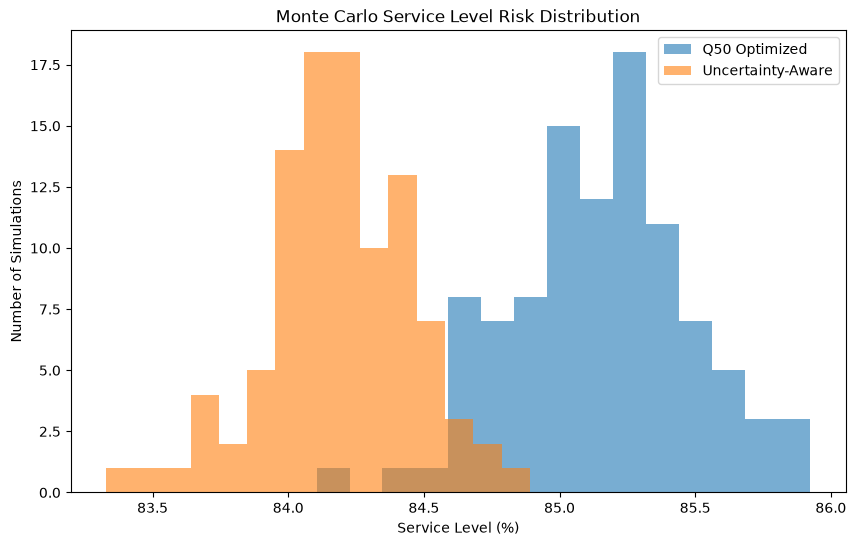

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(
    q50_summary["service_level"] * 100,
    bins=15,
    alpha=0.6,
    label="Q50 Optimized"
)

plt.hist(
    uncertain_summary["service_level"] * 100,
    bins=15,
    alpha=0.6,
    label="Uncertainty-Aware"
)

plt.xlabel("Service Level (%)")
plt.ylabel("Number of Simulations")
plt.title("Monte Carlo Service Level Risk Distribution")
plt.legend()
plt.show()

In [12]:
q50_percentiles = np.percentile(
    q50_summary["service_level"] * 100,
    [10, 50, 90]
)

uncertain_percentiles = np.percentile(
    uncertain_summary["service_level"] * 100,
    [10, 50, 90]
)

print("Q50 Optimized:")
print(f"P10 Service Level: {q50_percentiles[0]:.2f}%")
print(f"P50 Service Level: {q50_percentiles[1]:.2f}%")
print(f"P90 Service Level: {q50_percentiles[2]:.2f}%")

print("\nUncertainty-Aware:")
print(f"P10 Service Level: {uncertain_percentiles[0]:.2f}%")
print(f"P50 Service Level: {uncertain_percentiles[1]:.2f}%")
print(f"P90 Service Level: {uncertain_percentiles[2]:.2f}%")

Q50 Optimized:
P10 Service Level: 84.70%
P50 Service Level: 85.16%
P90 Service Level: 85.57%

Uncertainty-Aware:
P10 Service Level: 83.88%
P50 Service Level: 84.20%
P90 Service Level: 84.52%


In [13]:
risk_summary = pd.DataFrame({
    "Strategy": [
        "Q50 Optimized",
        "Uncertainty-Aware"
    ],
    "P10 Service Level": [
        q50_percentiles[0],
        uncertain_percentiles[0]
    ],
    "Median Service Level": [
        q50_percentiles[1],
        uncertain_percentiles[1]
    ],
    "P90 Service Level": [
        q50_percentiles[2],
        uncertain_percentiles[2]
    ],
    "Average Stockout": [
        q50_summary["total_stockout"].mean(),
        uncertain_summary["total_stockout"].mean()
    ]
})

risk_summary.to_csv(
    "../data/processed/monte_carlo_risk_summary.csv",
    index=False
)

risk_summary

,Strategy,P10 Service Level,Median Service Level,P90 Service Level,Average Stockout
0,Q50 Optimized,84.697973,85.164492,85.569161,343719.790746
1,Uncertainty-Aware,83.880881,84.203209,84.521949,366014.930744
